# 실습 6-1 : Clustering (K-Means, DBSCAN)

#### **<실습 내용>**

1. K-Means, DBSCAN 이해하기

2. Clustering 기반 RCA
- 반도체 공정 데이터 적용
- 연속형 변수 기반 클러스터링 (K-Means, DBSCAN)
- 연속형 + 범주형 기반 클러스터링 (K-Means, DBSCAN)

3. Vibe Coding 실습
- 통신사 고객 이탈 데이터 활용

## 분석 준비

### 주요 라이브러리 호출

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

from sklearn.datasets import make_blobs, make_moons  # 개념 설명용 가상 데이터 생성 함수

from sklearn.preprocessing import StandardScaler  # 변수 스케일링 (거리 기반 알고리즘엔 필수)
from sklearn.cluster import KMeans, DBSCAN        # 군집화 알고리즘 2종
from sklearn.metrics import silhouette_score       # 군집이 잘 나뉘었는지 점수로 평가하는 지표
from collections import Counter

---

## 1) K-Means, DBSCAN 이해하기

### 1-1) 가상 데이터 만들기

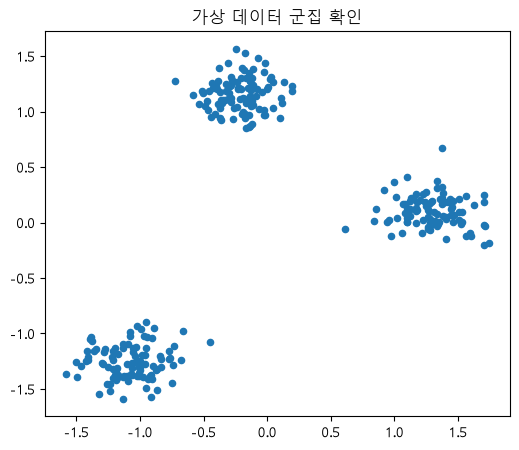

In [3]:
# make_blobs: 3개의 중심을 기준으로 뭉쳐진 가상 데이터 300개를 생성
# 군집이 몇 개인지 이미 아는 상태에서 알고리즘이 3개 군집을 잘 찾아내는지 확인하기 위함

X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# K-Means, DBSCAN은 '거리'로 유사도를 계산하므로, 변수 스케일이 다르면 거리 계산이 왜곡됨
# Standard Scaling을 통해 평균 0, 표준편차 1로 표준화

X = StandardScaler().fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=20)
plt.title("가상 데이터 군집 확인")
plt.show()

### 1-2) K-Means

> **K-Means**는 K개 군집의 중심(Centroid)을 반복적으로 갱신하여 데이터를 가장 가까운 군집에 배정하는 알고리즘임
> 1. 초기 K개의 중심을 선정 (기본값: `init='k-means++'`, 서로 멀리 떨어진 점들을 초기 중심으로 골라 랜덤 초기화보다 안정적인 결과를 줌)
> 2. 각 데이터를 가장 가까운 중심에 배정
> 3. 각 군집의 중심을 재계산
> 4. 중심이 변하지 않을 때까지 2-3 반복

In [4]:
# 1) 기본 K-Means: K를 임의로 3으로 지정하고 학습
# n_clusters: 생성할 군집수
# n_init: 초기 중심점을 몇 번 다르게 랜덤 배치해서 시도할지 
#         (10이면 10번 시도 후 가장 좋은 결과 채택)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# 데이터별 군집 학습 및 군집 번호 예측
cluster = kmeans.fit_predict(X)
cluster

array([1, 1, 2, 0, 1, 3, 2, 3, 2, 2, 2, 3, 2, 2, 1, 2, 1, 0, 2, 2, 2, 2,
       3, 1, 2, 4, 1, 0, 3, 2, 2, 2, 4, 2, 1, 2, 4, 3, 1, 3, 3, 2, 1, 0,
       2, 2, 4, 0, 4, 3, 3, 4, 4, 2, 4, 3, 4, 2, 3, 2, 4, 3, 3, 4, 1, 0,
       0, 4, 1, 2, 3, 4, 1, 2, 2, 4, 1, 0, 2, 3, 2, 2, 4, 2, 3, 4, 4, 2,
       3, 2, 1, 2, 4, 2, 2, 1, 1, 2, 1, 4, 0, 2, 0, 2, 2, 2, 2, 2, 3, 1,
       3, 2, 2, 2, 2, 3, 1, 0, 1, 0, 3, 3, 2, 4, 4, 1, 4, 2, 4, 1, 2, 2,
       2, 2, 2, 3, 0, 1, 2, 1, 2, 2, 4, 2, 0, 0, 3, 2, 3, 2, 2, 4, 3, 1,
       2, 0, 3, 1, 4, 2, 2, 1, 4, 4, 2, 4, 0, 2, 2, 2, 2, 2, 0, 2, 0, 3,
       3, 2, 3, 3, 4, 2, 1, 3, 3, 1, 3, 2, 0, 0, 4, 4, 0, 1, 0, 0, 3, 3,
       2, 4, 2, 2, 0, 0, 2, 3, 1, 1, 3, 2, 2, 1, 3, 0, 4, 4, 4, 4, 2, 1,
       4, 0, 1, 1, 2, 0, 1, 4, 0, 2, 2, 4, 2, 1, 3, 3, 1, 3, 4, 1, 4, 3,
       3, 2, 4, 0, 3, 3, 4, 3, 4, 0, 1, 3, 3, 4, 0, 2, 1, 2, 2, 2, 4, 2,
       3, 0, 4, 3, 3, 2, 2, 3, 0, 3, 4, 4, 1, 2, 2, 2, 0, 3, 3, 0, 4, 3,
       4, 3, 0, 4, 2, 0, 3, 2, 1, 2, 0, 2, 4, 4], d

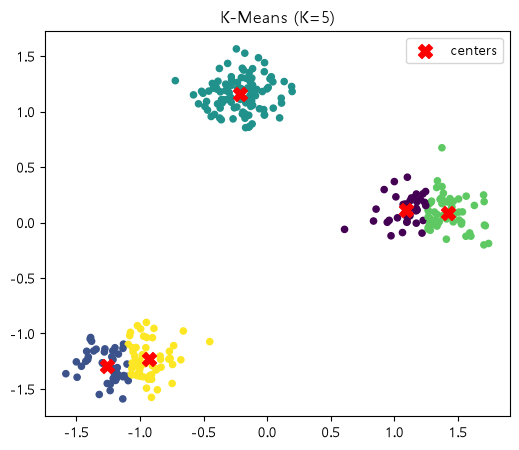

In [5]:
plt.figure(figsize=(6, 5))  

# c: 각 점의 색상을 지정하는 값 (여기선 군집 번호로 색 구분)
# labels_: 각 데이터가 어느 군집에 배정됐는지 (fit_predict 결과와 동일)
# s: 점 크기
# cmap: 색상 팔레트 (viridis는 연속형 색상 매핑)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=20, cmap='viridis')

# cluster_centers_: 학습된 각 군집의 중심 좌표
# c='red': 중심점 색상 고정
# marker='X': 점 모양을 X자로 표시 
# s=200: 중심점은 크게 표시해서 눈에 띄게 함
# label='centers': 범례(legend)에 표시될 이름

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=100, label='centers')

plt.title("K-Means (K=5)")  
plt.legend()  
plt.show()

#### K 값에 따른 결과 비교

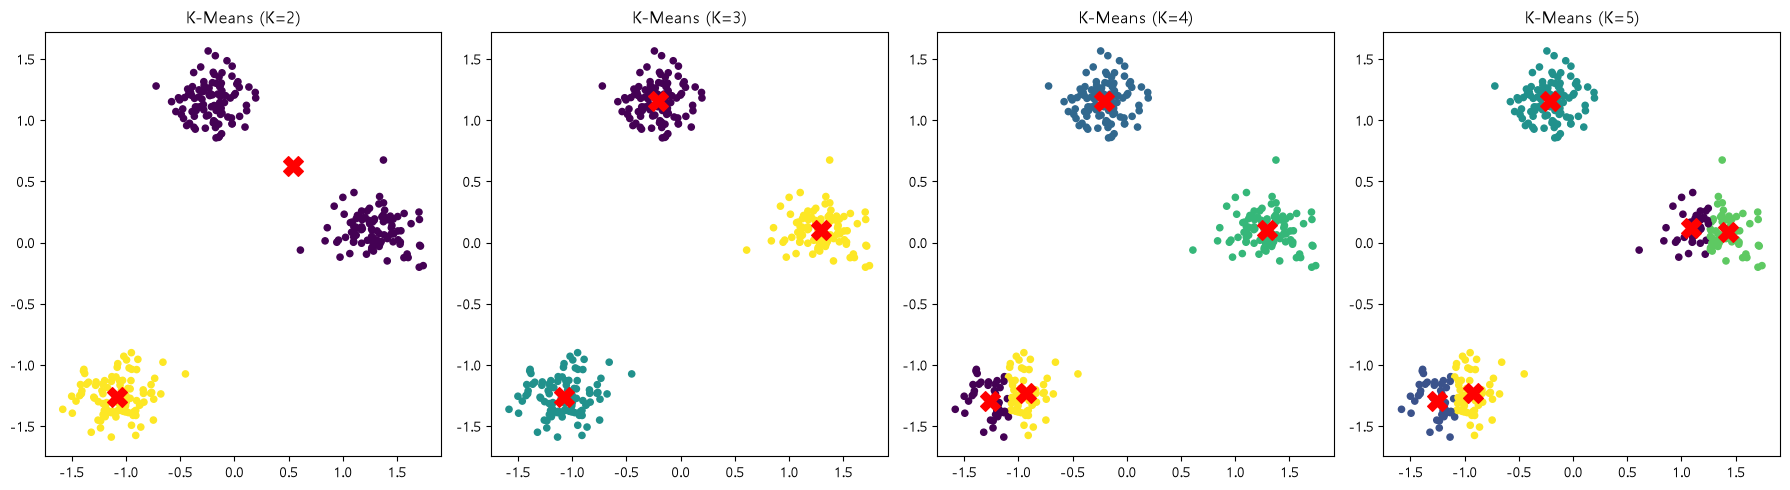

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, k in zip(axes, [2, 3, 4, 5]):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=20, cmap='viridis')  # labels_: 각 데이터가 배정된 군집 번호
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)  # cluster_centers_: 학습된 군집 중심 좌표
    ax.set_title(f"K-Means (K={k})")

plt.tight_layout()
plt.show()

#### Silhouette Method로 최적 K 결정

> **Silhouette Score**는 각 데이터가 자신이 속한 군집과 얼마나 잘 맞는지를 측정함
> - 1에 가까울수록 올바른 군집
> - K를 변화시키며 평균 Silhouette Score가 최대인 K를 선택

In [7]:
sil_scores = []
K_range = range(2, 10)  # K를 2~9까지 바꿔가며 비교

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit_predict(X)
    # silhouette_score: 군집이 얼마나 잘 나뉘었는지를 -1~1 사이 숫자로 요약
    # 1에 가까울수록 좋음
    sil_scores.append(silhouette_score(X, kmeans.labels_))

best_k = K_range[np.argmax(sil_scores)]  # 점수가 가장 높은 K를 최적 K로 선택
print(f"최적 K: {best_k} (Silhouette Score: {max(sil_scores):.3f})")

최적 K: 3 (Silhouette Score: 0.848)


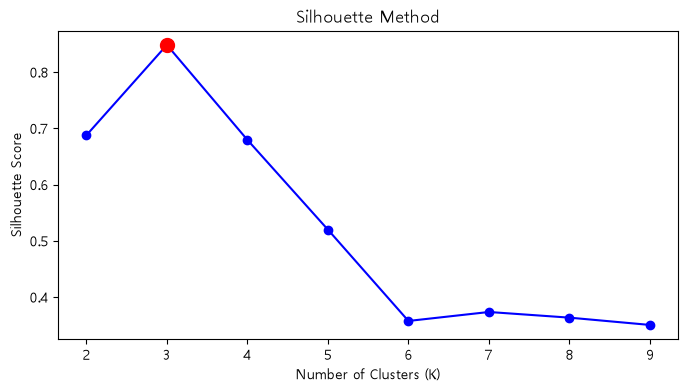

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'bo-')  # K별 실루엣 점수 선 그래프

# best_k 지점만 빨간 점으로 강조 표시
plt.scatter(best_k, max(sil_scores), c='red', s=100, zorder=5)

plt.xlabel("Number of Clusters (K)")    # x축 라벨: K 값
plt.ylabel("Silhouette Score")          # y축 라벨: 실루엣 점수 (1에 가까울수록 군집 잘 나뉨)
plt.title("Silhouette Method")         
plt.xticks(K_range)                  
plt.show()

---

### 1-3) DBSCAN

> **DBSCAN**은 밀도 기반 클러스터링으로 데이터가 많이 모여 있는 영역을 하나의 군집으로 인식하는 방법임 (군집 수를 미리 지정할 필요가 없음)
>
> - **eps**: 이웃으로 인정할 최대 거리
> - **min_samples**: 하나의 군집으로 인정하기 위한 최소 이웃 수
> - **Core Point**: 주변에 이웃이 충분히 많은 중심 데이터
> - **Border Point**: 군집 가장자리에 위치한 데이터
> - **Noise Point**: 어떤 군집에도 속하지 않는 이상치 데이터 (label = -1)
>
> DBSCAN은 이상 탐지에도 유용함

In [9]:
# eps: 이웃으로 인정할 최대 거리 (이 반경 안에 점이 몰려있으면 같은 군집)
# min_samples: 하나의 군집으로 인정하기 위한 최소 이웃 수
dbscan = DBSCAN(eps=0.5, min_samples=5)

# 데이터별 군집 학습 및 군집 번호 예측
# DBSCAN은 K-Means와 달리 노이즈(어느 군집에도 속하지 않는 점)를 -1로 표시
cluster = dbscan.fit_predict(X)
cluster

array([0, 0, 1, 2, 0, 2, 1, 2, 1, 1, 1, 2, 1, 1, 0, 1, 0, 2, 1, 1, 1, 1,
       2, 0, 1, 0, 0, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 2, 0, 2, 2, 1, 0, 2,
       1, 1, 0, 2, 0, 2, 2, 0, 0, 1, 0, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 2,
       2, 0, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 1, 2, 1, 1, 0, 1, 2, 0, 0, 1,
       2, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1, 2, 0,
       2, 1, 1, 1, 1, 2, 0, 2, 0, 2, 2, 2, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 2, 2, 0, 1, 0, 1, 1, 0, 1, 2, 2, 2, 1, 2, 1, 1, 0, 2, 0,
       1, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2,
       2, 1, 2, 2, 0, 1, 0, 2, 2, 0, 2, 1, 2, 2, 0, 0, 2, 0, 2, 2, 2, 2,
       1, 0, 1, 1, 2, 2, 1, 2, 0, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 0, 1, 0,
       0, 2, 0, 0, 1, 2, 0, 0, 2, 1, 1, 0, 1, 0, 2, 2, 0, 2, 0, 0, 0, 2,
       2, 1, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 1, 0, 1, 1, 1, 0, 1,
       2, 2, 0, 2, 2, 1, 1, 2, 2, 2, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 0, 1, 2, 2, 1, 0, 1, 2, 1, 0, 0])

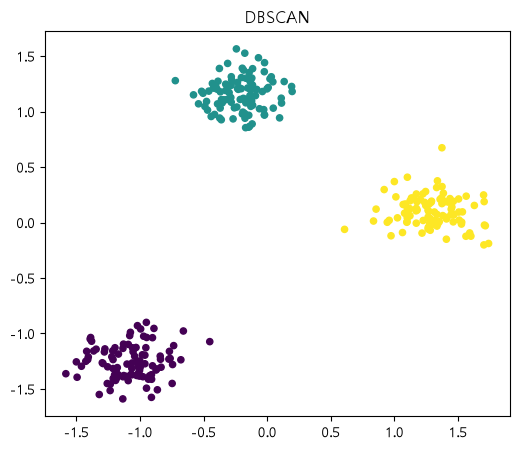

In [10]:
plt.figure(figsize=(6, 5))

# c: 군집 번호로 색 구분 (-1은 노이즈, 보통 다른 색으로 튐)
plt.scatter(X[:, 0], X[:, 1], c=cluster, s=20, cmap='viridis')
plt.title("DBSCAN")
plt.show()

#### eps 값에 따른 결과 비교

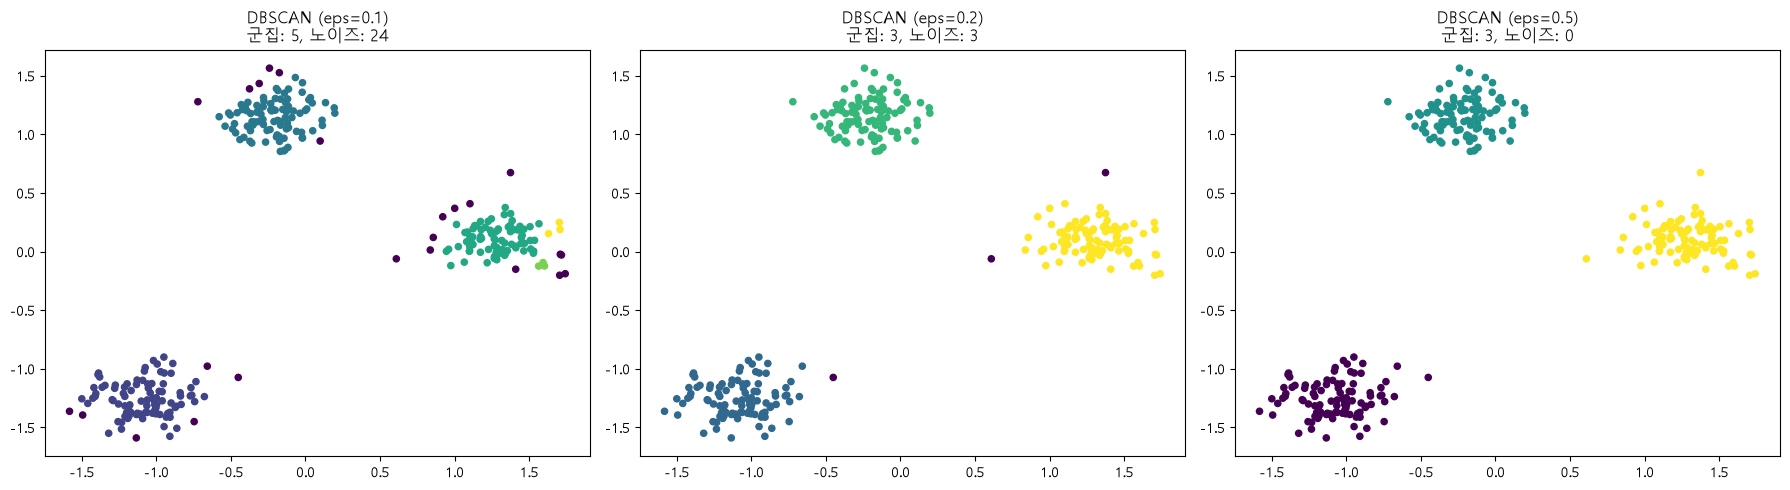

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, eps in zip(axes, [0.1, 0.2, 0.5]):
    # eps: 이웃으로 인정할 반경 / min_samples: Core Point가 되기 위한 최소 이웃 수
    dbscan = DBSCAN(eps=eps, min_samples=3)
    dbscan.fit_predict(X)

    n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)  # 라벨 -1(노이즈)은 군집 수에서 제외하고 계산
    n_noise = list(dbscan.labels_).count(-1)  # 어떤 군집에도 속하지 못한 노이즈 데이터 개수

    ax.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, s=20, cmap='viridis')
    ax.set_title(f"DBSCAN (eps={eps})\n군집: {n_clusters}, 노이즈: {n_noise}")
plt.tight_layout()
plt.show()

#### K-distance Plot으로 최적 eps 결정

> **eps** : 두 데이터를 이웃으로 판단하기 위한 최대 거리

- **K-distance Plot**
  - 각 데이터의 K번째 최근접 이웃까지의 거리를 계산한 후, 이를 오름차순으로 정렬하여 나타낸 그래프

- **eps 선택 방법**
  - 그래프에서 거리가 급격히 증가하기 시작하는 지점(Elbow Point)의 거리 값을 eps로 선택

- **해석**
  - 그래프가 완만한 구간 → 군집 내부 데이터
  - 그래프가 급격히 상승하는 구간 → 이상치(Noise) 후보
  - Elbow Point의 y값 → 적절한 eps 후보

- **의미**
  - Elbow Point 이전의 데이터는 군집에 속할 가능성이 높음
  - Elbow Point 이후의 데이터는 이상치(Noise)일 가능성이 높음

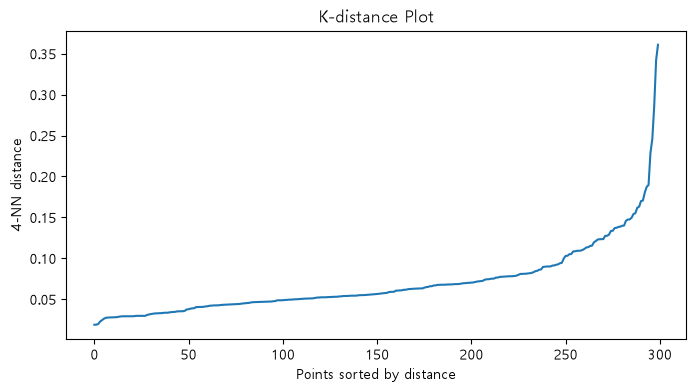

In [13]:
from sklearn.neighbors import NearestNeighbors

# min_samples를 먼저 정해야 k-distance 계산 가능 
# 보통 min_samples = 데이터 차원수*2
# 현재 예시는 2차원이니 min_samples=4~5 근처로 시작

min_samples = 4

# 각 점마다 자신을 포함해 min_samples번째로 가까운 이웃까지의 거리 계산
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# min_samples번째 이웃까지의 거리만 추출 후 오름차순 정렬
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot")
plt.show()

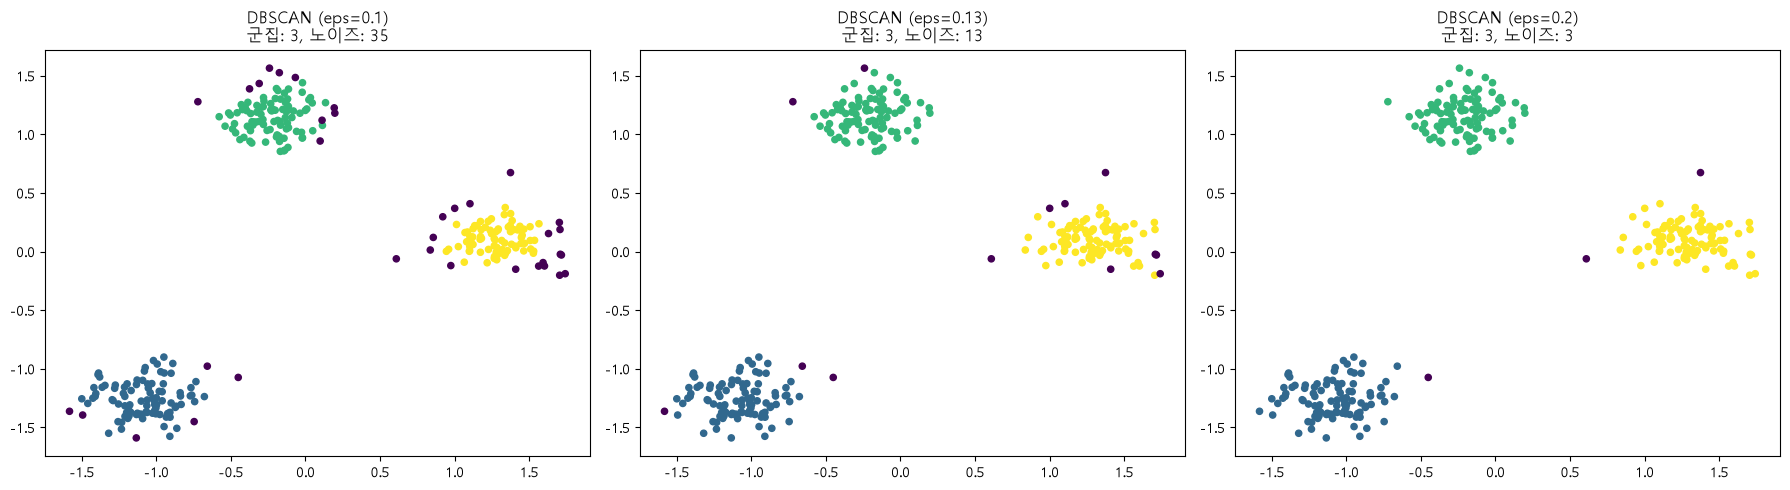

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# k-distance plot의 기준으로 주변 최적의 eps 후보 비교
for ax, eps in zip(axes, [0.1, 0.13, 0.2]):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit_predict(X)

    n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
    n_noise = list(dbscan.labels_).count(-1)

    ax.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, s=20, cmap='viridis')
    ax.set_title(f"DBSCAN (eps={eps})\n군집: {n_clusters}, 노이즈: {n_noise}")
plt.tight_layout()
plt.show()

### 1-4) 비선형 데이터에서 K-Means vs DBSCAN

> DBSCAN은 다양한 모양의 군집을 형성할 수 있어 K-Means가 잘 작동하지 않는 비선형 데이터에서 강점을 보임

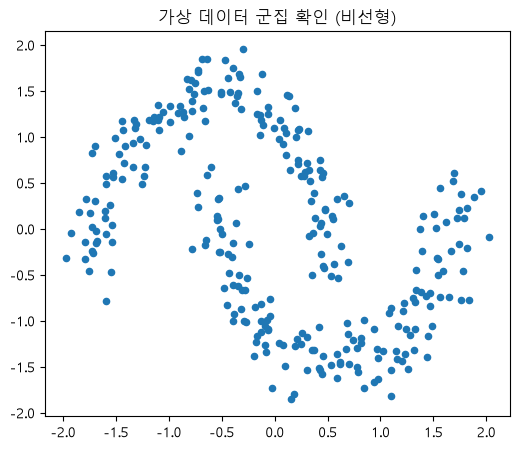

In [15]:
# 1) 가상 데이터 만들기
# make_moons: 초승달 모양 2개가 맞물린 비선형 데이터 
X_moon, y_moon = make_moons(n_samples=300, noise=0.1, random_state=42)

# K-Means, DBSCAN은 '거리'로 유사도를 계산하므로, 변수 스케일이 다르면 거리 계산이 왜곡됨
# Standard Scaling을 통해 평균 0, 표준편차 1로 표준화

X_moon = StandardScaler().fit_transform(X_moon)

plt.figure(figsize=(6, 5))
plt.scatter(X_moon[:, 0], X_moon[:, 1], s=20)
plt.title("가상 데이터 군집 확인 (비선형)")
plt.show()

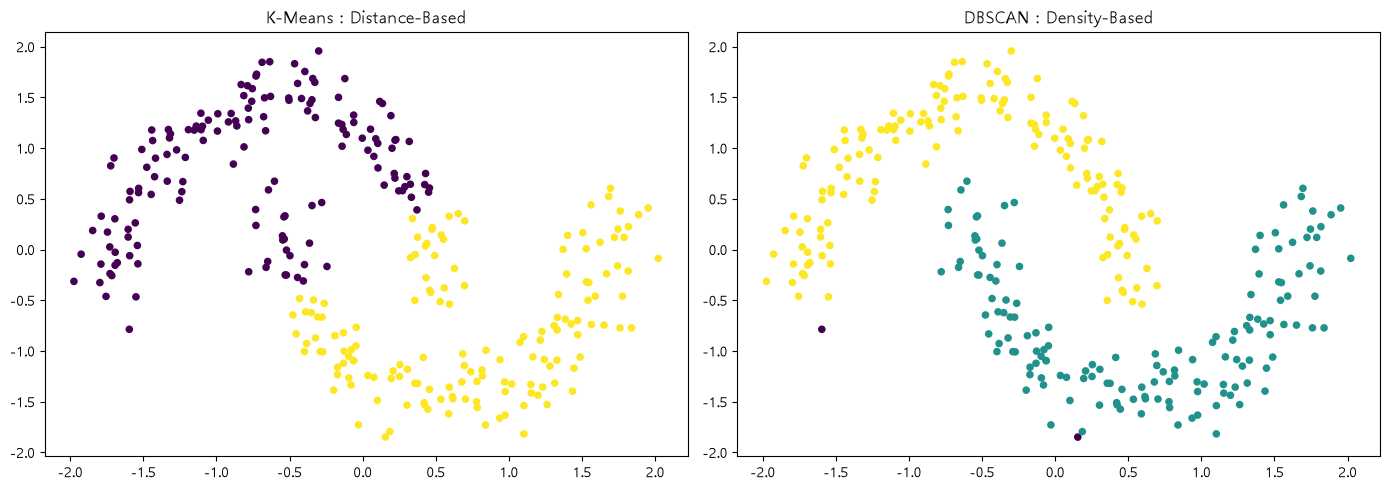

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means: '중심까지의 거리'만 고려함
kmeans_moon = KMeans(n_clusters=2, random_state=0, n_init=10)
kmeans_moon.fit_predict(X_moon)
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=kmeans_moon.labels_, s=20, cmap='viridis')
axes[0].set_title("K-Means : Distance-Based")

# DBSCAN: '밀도가 이어지는지'로 판단함
dbscan_moon = DBSCAN(eps=0.3, min_samples=5)
dbscan_moon.fit_predict(X_moon)
axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=dbscan_moon.labels_, s=20, cmap='viridis')
axes[1].set_title("DBSCAN : Density-Based")

plt.tight_layout()
plt.show()

## 2) Clustering 기반 RCA 수행

**활용할 반도체 공정 데이터 소개**

| 변수 | 설명 |
|---|---|
| Prod_ID | 제품 고유 ID |
| M1 | 공정 설비 온도 설정값 (15/20/25/30) |
| M2 | 사용 설비 ID (E, U, K) |
| P1 ~ P6 | 제품 설계/공정 옵션 (범주형 파라미터) |
| C1, C2 | 공정 중 측정된 연속형 값 |
| Y | 제품 1개당 발생한 불량 개수 |
| Fail | Y >= 3이면 Fault, 아니면 Pass로 정의한 라벨 |

In [17]:
data = pd.read_csv("dataset/day6-1_data.csv")

# 조건 기반 타겟변수 생성
data["Fail"] = ["Fault" if y >= 3 else "Pass" for y in data["Y"]]
print("데이터 크기:", data.shape)
data.head()

데이터 크기: (596, 13)


,Prod_ID,M1,M2,P1,P2,P3,C1,C2,P4,P5,P6,Y,Fail
0,1001001,15,E,A,B,D,110.192,27.049,A,A,B,0,Pass
1,1001002,20,E,A,B,D,109.940,27.215,A,A,A,0,Pass
2,1001003,15,U,A,B,B,110.214,27.444,B,B,B,4,Fault
3,1001004,25,K,B,B,C,107.260,27.300,A,A,C,0,Pass
4,1001005,20,E,A,A,D,105.026,28.283,B,B,A,0,Pass


In [18]:
print(data["Fail"].value_counts())

Fail
Pass     471
Fault    125
Name: count, dtype: int64


### 2-1) 연속형 변수만 활용한 경우

In [19]:
num_cols = ["C1", "C2"]

# 거리 기반 알고리즘이므로 표준화 필수
X_num = StandardScaler().fit_transform(data[num_cols])

#### K-Menas

> Silhouette 기반 최적 K 찾기

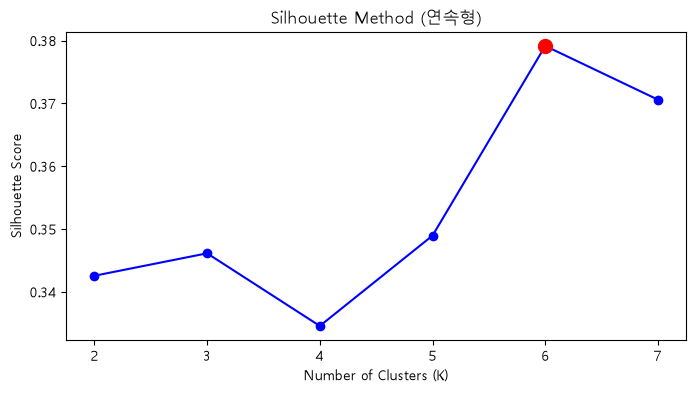

최적 K: 6


In [20]:
K_range = range(2, 8)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_num)
    score = silhouette_score(X_num, labels)  # 군집이 잘 나뉠수록 1에 가까움
    sil_scores.append(score)

best_k = K_range[np.argmax(sil_scores)]  # 실루엣 점수가 가장 높은 K

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'bo-')
plt.scatter(best_k, max(sil_scores), c='red', s=100, zorder=5)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method (연속형)")
plt.xticks(K_range)
plt.show()

print("최적 K:", best_k)

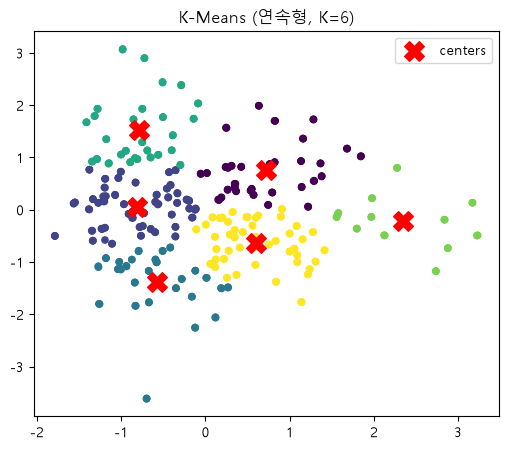

In [21]:
# 최적 K로 최종 K-Means 학습
kmeans_num = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data["cluster_kmeans_num"] = kmeans_num.fit_predict(X_num)

plt.figure(figsize=(6, 5))
plt.scatter(X_num[:, 0], X_num[:, 1], c=data["cluster_kmeans_num"], s=20, cmap='viridis')
plt.scatter(kmeans_num.cluster_centers_[:, 0], kmeans_num.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='centers')
plt.title(f"K-Means (연속형, K={best_k})")
plt.legend()
plt.show()

#### DBSCAN

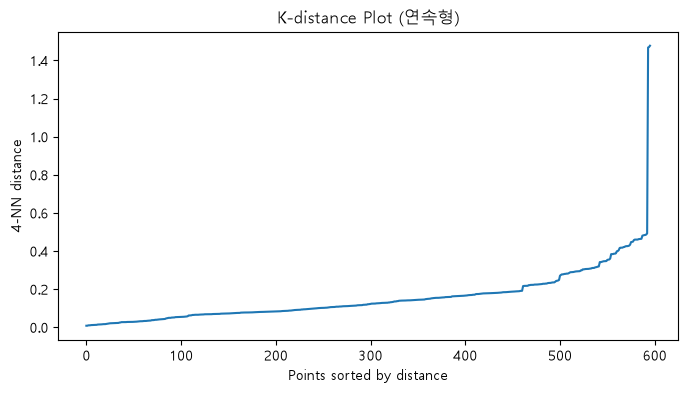

In [22]:
min_samples = 4  # 2차원 데이터 기준 통상 4~5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_num)
distances, indices = neighbors_fit.kneighbors(X_num)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot (연속형)")
plt.show()

군집 수: 7, 노이즈: 33


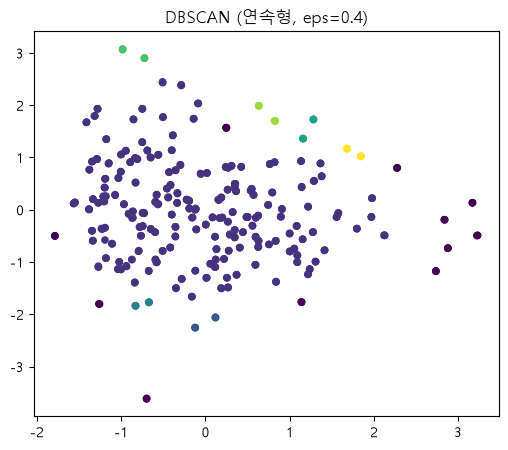

In [23]:
# 위 그래프의 elbow 지점 y값으로 교체
eps_num = 0.4 

dbscan_num = DBSCAN(eps=eps_num, min_samples=min_samples)
data["cluster_dbscan_num"] = dbscan_num.fit_predict(X_num)

n_clusters = len(set(data["cluster_dbscan_num"])) - (1 if -1 in data["cluster_dbscan_num"].values else 0)
n_noise = (data["cluster_dbscan_num"] == -1).sum()
print(f"군집 수: {n_clusters}, 노이즈: {n_noise}")

plt.figure(figsize=(6, 5))
plt.scatter(X_num[:, 0], X_num[:, 1], c=data["cluster_dbscan_num"], s=20, cmap='viridis')
plt.title(f"DBSCAN (연속형, eps={eps_num})")
plt.show()

#### RCA 진행

1. 군집에 속한 데이터의 특성이 비슷한지 확인
2. 군집별 연속형 변수 값 비교

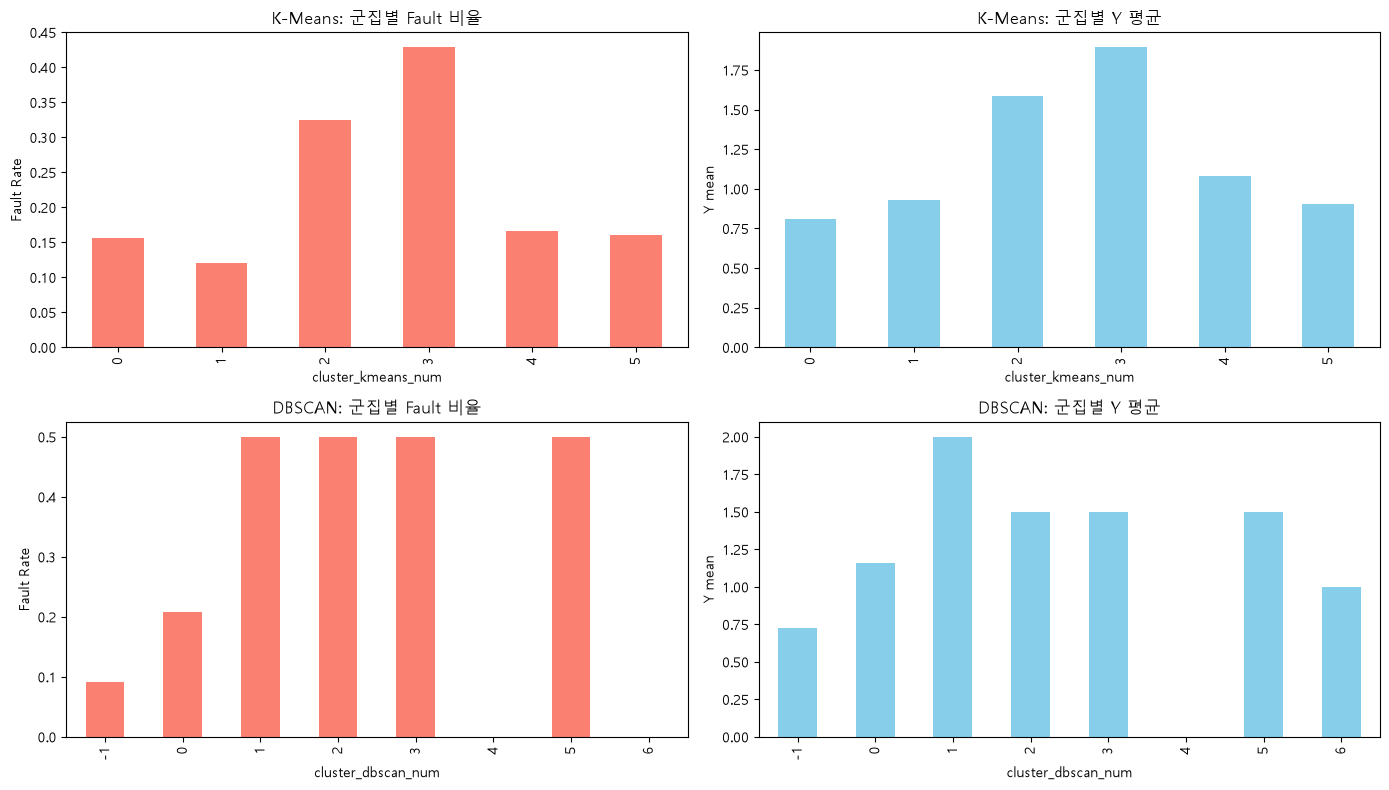

In [24]:
# 1. 군집이 Fail/Y와 관련 있는지 확인

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# K-Means: 군집별 Fault 비율
kmeans_fault_rate = data.groupby("cluster_kmeans_num")["Fail"].apply(lambda x: (x == "Fault").mean())
kmeans_fault_rate.plot(kind="bar", ax=axes[0, 0], color="salmon")
axes[0, 0].set_title("K-Means: 군집별 Fault 비율")
axes[0, 0].set_ylabel("Fault Rate")

# K-Means: 군집별 Y 평균
data.groupby("cluster_kmeans_num")["Y"].mean().plot(kind="bar", ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("K-Means: 군집별 Y 평균")
axes[0, 1].set_ylabel("Y mean")

# DBSCAN: 군집별 Fault 비율
dbscan_fault_rate = data.groupby("cluster_dbscan_num")["Fail"].apply(lambda x: (x == "Fault").mean())
dbscan_fault_rate.plot(kind="bar", ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("DBSCAN: 군집별 Fault 비율")
axes[1, 0].set_ylabel("Fault Rate")

# DBSCAN: 군집별 Y 평균
data.groupby("cluster_dbscan_num")["Y"].mean().plot(kind="bar", ax=axes[1, 1], color="skyblue")
axes[1, 1].set_title("DBSCAN: 군집별 Y 평균")
axes[1, 1].set_ylabel("Y mean")

plt.tight_layout()
plt.show()

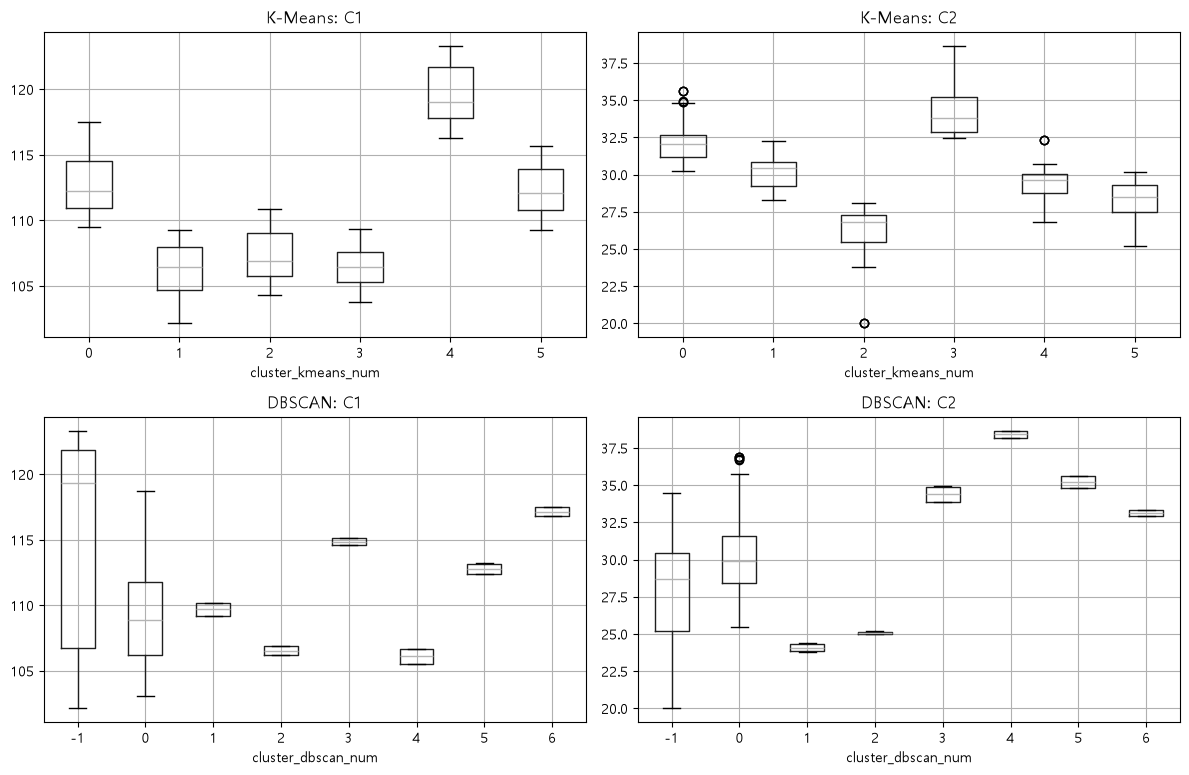

In [25]:
# 2. 군집별 연속형 변수(C1, C2) 값 비교 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

data.boxplot(column="C1", by="cluster_kmeans_num", ax=axes[0, 0])
axes[0, 0].set_title("K-Means: C1")

data.boxplot(column="C2", by="cluster_kmeans_num", ax=axes[0, 1])
axes[0, 1].set_title("K-Means: C2")

data.boxplot(column="C1", by="cluster_dbscan_num", ax=axes[1, 0])
axes[1, 0].set_title("DBSCAN: C1")

data.boxplot(column="C2", by="cluster_dbscan_num", ax=axes[1, 1])
axes[1, 1].set_title("DBSCAN: C2")

plt.suptitle("")  # boxplot 자동 상위 제목 제거
plt.tight_layout()
plt.show()

---

### 2-2) 모든 변수를 활용한 경우

In [26]:
cat_cols = ["M1", "M2", "P1", "P2", "P3", "P4", "P5", "P6"]
num_cols = ["C1", "C2"]

# 범주형은 원-핫 인코딩, 연속형은 표준화해서 하나의 행렬로 합침
X_cat = pd.get_dummies(data[cat_cols].astype("object"))
X_cat[num_cols] = StandardScaler().fit_transform(data[num_cols])

#### K-Means

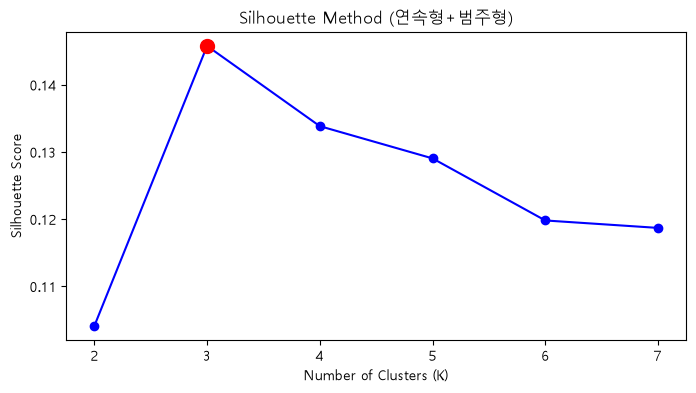

최적 K: 3


In [28]:
K_range = range(2, 8)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cat)
    score = silhouette_score(X_cat, labels)
    sil_scores.append(score)

best_k = K_range[np.argmax(sil_scores)]

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'bo-')
plt.scatter(best_k, max(sil_scores), c='red', s=100, zorder=5)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method (연속형+범주형)")
plt.xticks(K_range)
plt.show()

print("최적 K:", best_k)

In [29]:
kmeans_full = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data["cluster_kmeans_full"] = kmeans_full.fit_predict(X_cat)

#### DBSCAN

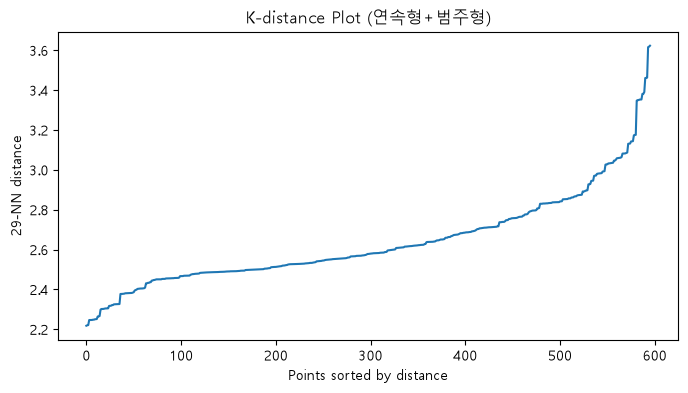

In [30]:
min_samples = X_cat.shape[1] + 1  # 차원이 늘어났으니 min_samples도 늘림

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_cat)
distances, indices = neighbors_fit.kneighbors(X_cat)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot (연속형+범주형)")
plt.show()

In [31]:
# 위 그래프의 elbow 지점 y값으로 교체
eps_full = 2.7

dbscan_full = DBSCAN(eps=eps_full, min_samples=min_samples)
data["cluster_dbscan_full"] = dbscan_full.fit_predict(X_cat)

n_clusters = len(set(data["cluster_dbscan_full"])) - (1 if -1 in data["cluster_dbscan_full"].values else 0)
n_noise = (data["cluster_dbscan_full"] == -1).sum()
print(f"군집 수: {n_clusters}, 노이즈: {n_noise}")

군집 수: 1, 노이즈: 24


#### RCA 진행

1. 군집에 속한 데이터의 특성이 비슷한지 확인
2. 군집별 연속형/범주형 변수 값 비교

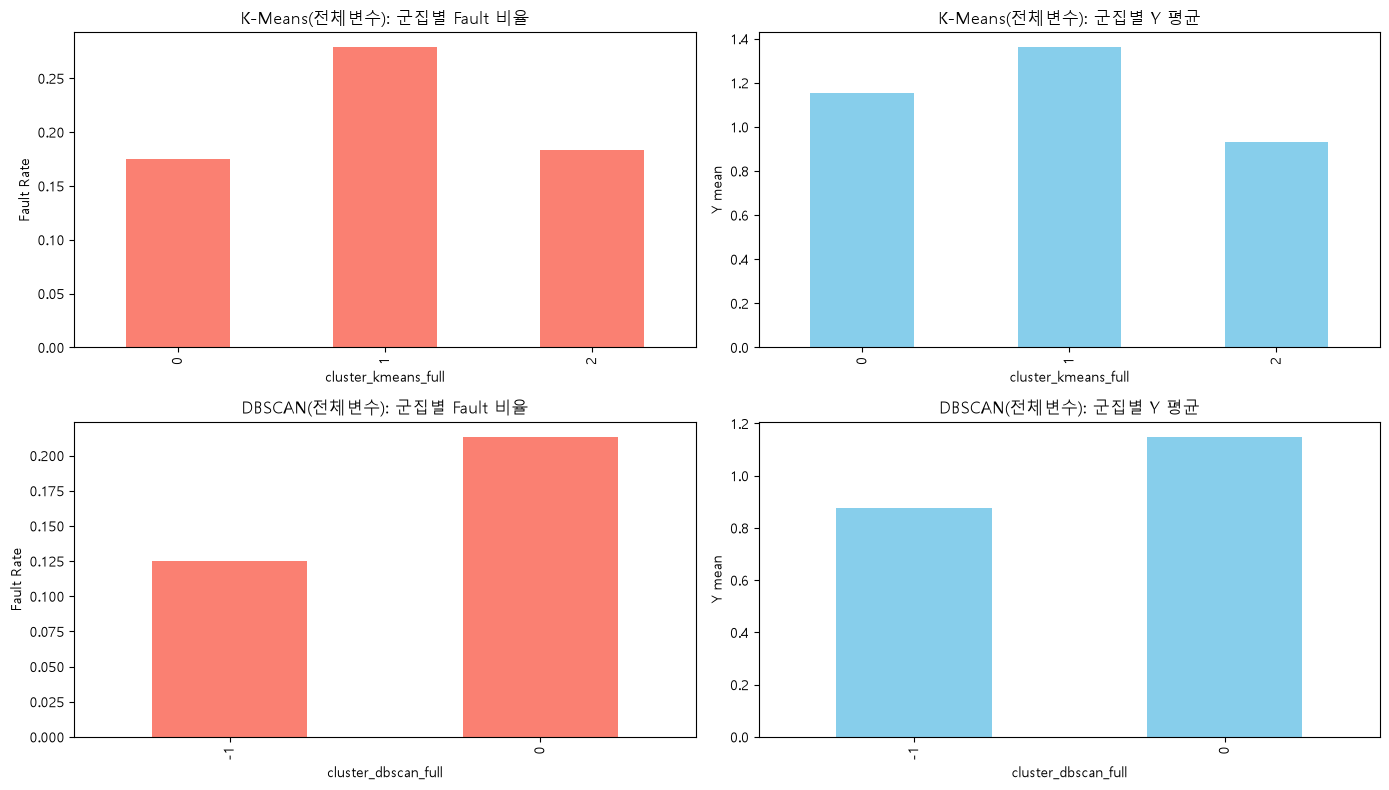

In [32]:
# 1. 군집이 Fail/Y와 관련 있는지 확인

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

kmeans_fault_rate = data.groupby("cluster_kmeans_full")["Fail"].apply(lambda x: (x == "Fault").mean())
kmeans_fault_rate.plot(kind="bar", ax=axes[0, 0], color="salmon")
axes[0, 0].set_title("K-Means(전체변수): 군집별 Fault 비율")
axes[0, 0].set_ylabel("Fault Rate")

data.groupby("cluster_kmeans_full")["Y"].mean().plot(kind="bar", ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("K-Means(전체변수): 군집별 Y 평균")
axes[0, 1].set_ylabel("Y mean")

dbscan_fault_rate = data.groupby("cluster_dbscan_full")["Fail"].apply(lambda x: (x == "Fault").mean())
dbscan_fault_rate.plot(kind="bar", ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("DBSCAN(전체변수): 군집별 Fault 비율")
axes[1, 0].set_ylabel("Fault Rate")

data.groupby("cluster_dbscan_full")["Y"].mean().plot(kind="bar", ax=axes[1, 1], color="skyblue")
axes[1, 1].set_title("DBSCAN(전체변수): 군집별 Y 평균")
axes[1, 1].set_ylabel("Y mean")

plt.tight_layout()
plt.show()

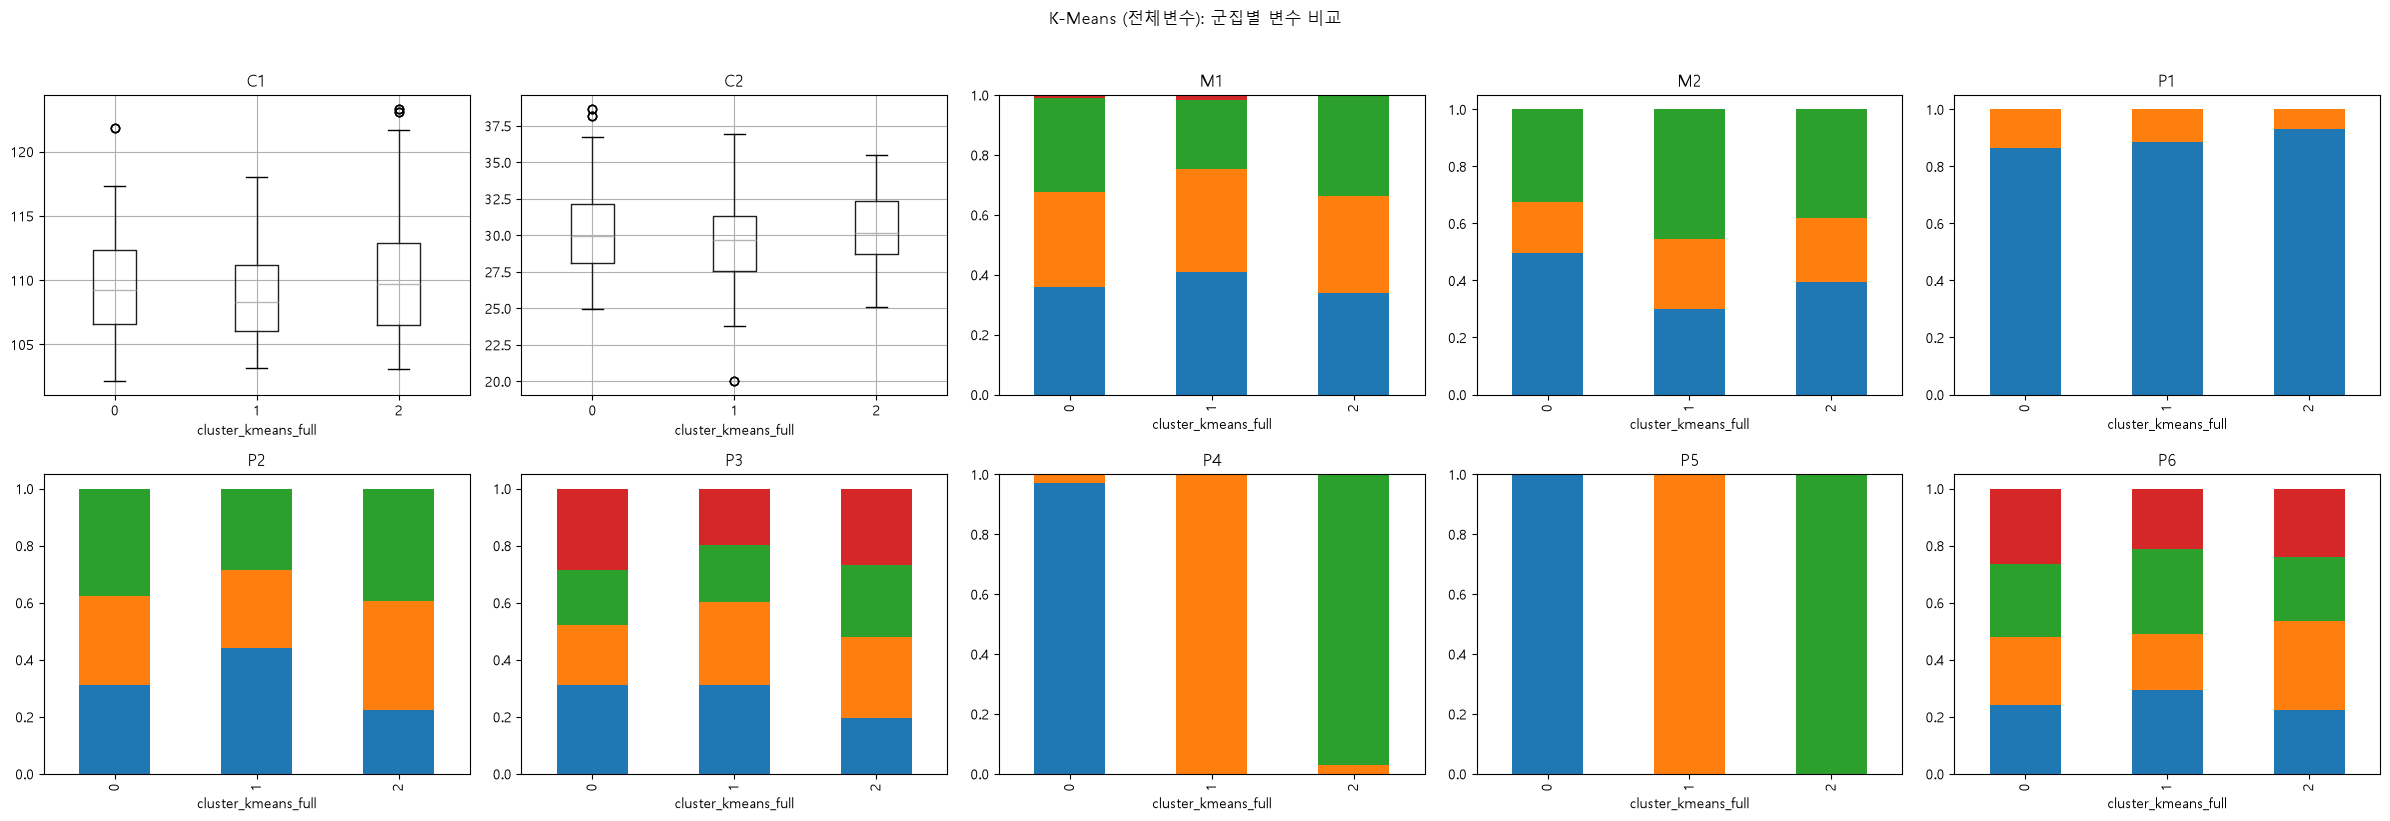

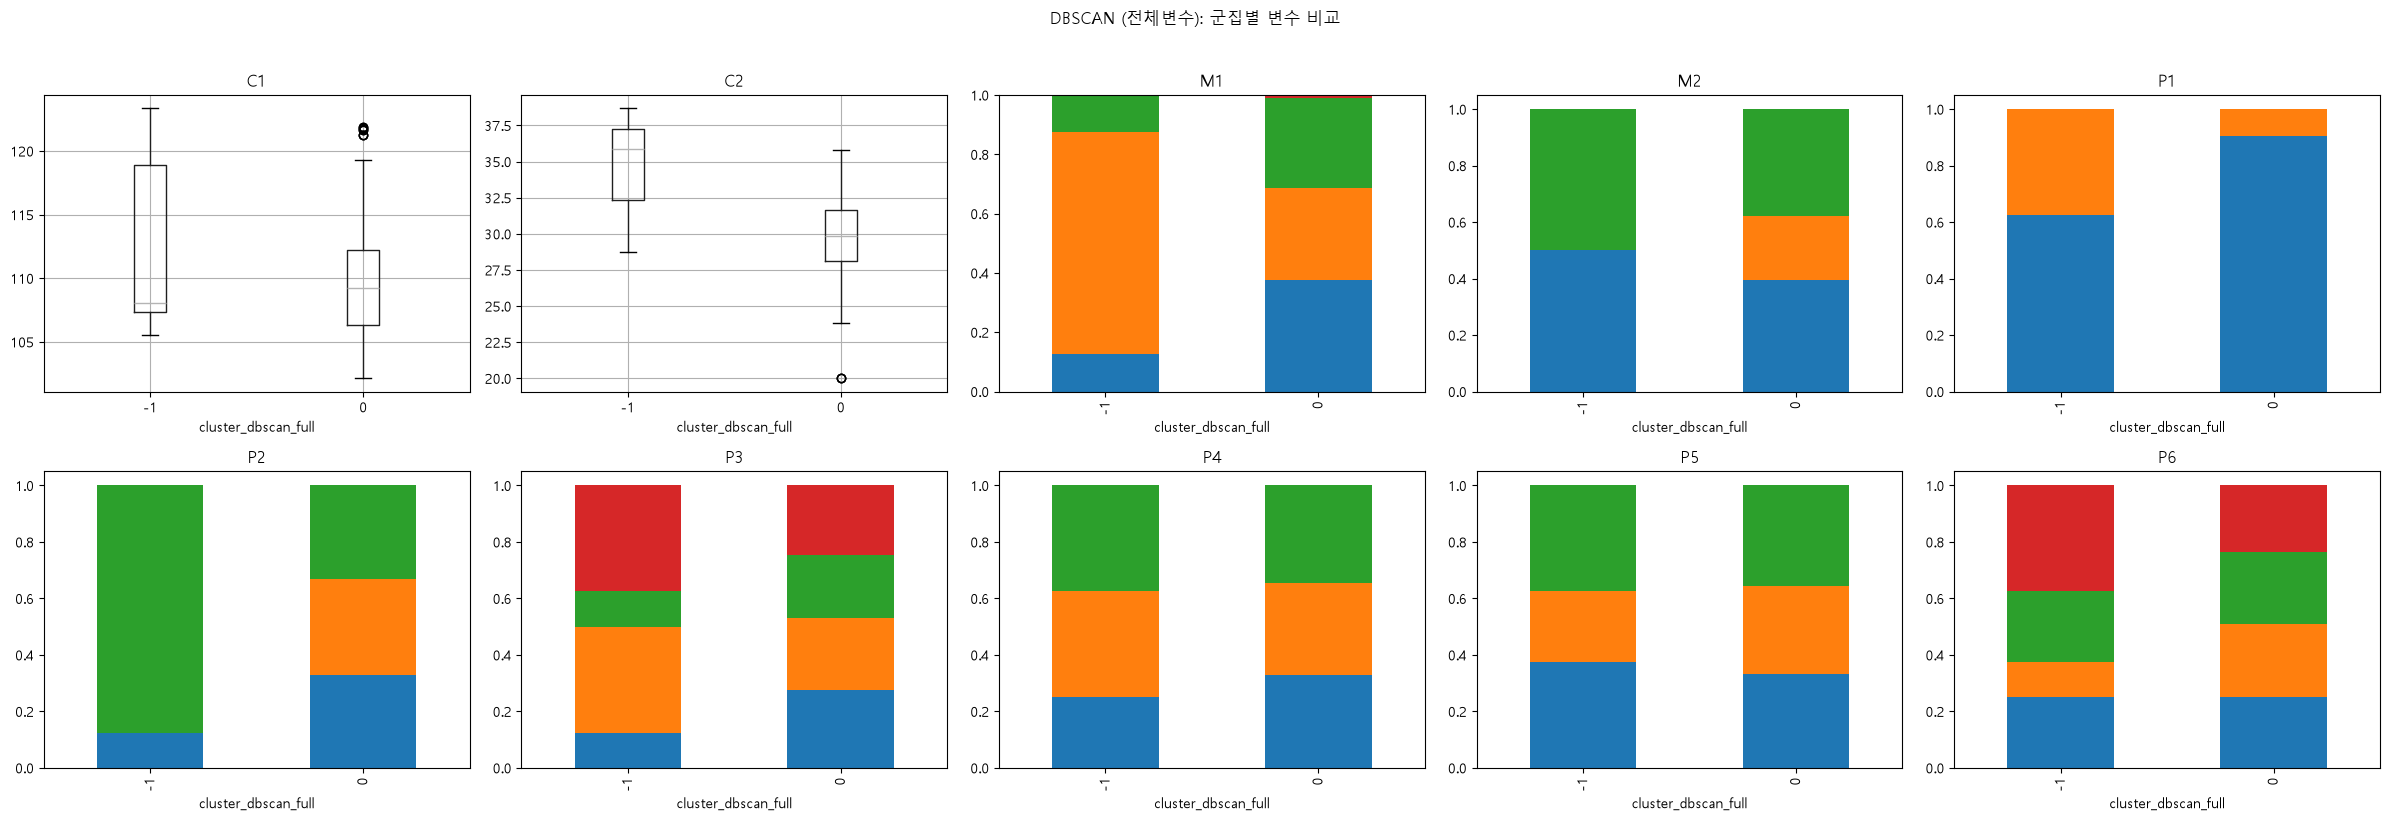

In [33]:
# 2. 군집별 연속형/범주형 변수 값 비교 

# 1) K-Means
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.flatten()

# 연속형 2개
data.boxplot(column="C1", by="cluster_kmeans_full", ax=axes[0])
axes[0].set_title("C1")

data.boxplot(column="C2", by="cluster_kmeans_full", ax=axes[1])
axes[1].set_title("C2")

# 범주형 8개
cat_cols = ["M1", "M2", "P1", "P2", "P3", "P4", "P5", "P6"]
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(data["cluster_kmeans_full"], data[col], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i + 2], legend=False)
    axes[i + 2].set_title(col)

plt.suptitle("K-Means (전체변수): 군집별 변수 비교", y=1.02)
plt.tight_layout()
plt.show()

# 2) DBSCAN
fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.flatten()

data.boxplot(column="C1", by="cluster_dbscan_full", ax=axes[0])
axes[0].set_title("C1")

data.boxplot(column="C2", by="cluster_dbscan_full", ax=axes[1])
axes[1].set_title("C2")

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(data["cluster_dbscan_full"], data[col], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i + 2], legend=False)
    axes[i + 2].set_title(col)

plt.suptitle("DBSCAN (전체변수): 군집별 변수 비교", y=1.02)
plt.tight_layout()
plt.show()

---

## 3) Vibe Coding 실습

K-Means, DBSCAN을 **통신사 고객 이탈(Customer Churn) 데이터셋**에 직접 적용해 봅니다.

- `dataset/day6_vibecoding.csv` 파일 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

In [35]:
# 필요한 라이브러리 호출하기
from sklearn.impute import KNNImputer

# 0. 데이터 불러오기
data = pd.read_csv('dataset/day6_vibecoding.csv')

# 1. 결측치 처리
# 범주형(InternetService, PaymentMethod) → 최빈값 대치
for col in ['InternetService', 'PaymentMethod']:
    data[col] = data[col].fillna(data[col].mode()[0])

# TotalCharges → 중앙값 대치
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# tenure, MonthlyCharges → KNN Imputer (비슷한 고객들의 값을 참고해 대치)
knn_cols = ['tenure', 'MonthlyCharges']
imputer = KNNImputer(n_neighbors=5)
data[knn_cols] = imputer.fit_transform(data[knn_cols])

# 2. 군집화에 쓰지 않을 컬럼 분리 
# Churn: 군집화 단계에서는 사용하지 않고, 군집 해석(군집별 이탈률 비교) 시에만 참고
churn = data['Churn']
X = data.drop(columns=['Churn'])

# 3. 수치형 변수 스케일링 
# K-Means/DBSCAN은 거리 기반이라 변수 스케일이 다르면 특정 변수가 거리 계산을 왜곡할 수 있음
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# 4. 범주형 변수 인코딩 
# 값이 2개뿐인 이진 범주형 변수는 0/1로 Label Encoding
binary_map = {
    'gender':           {'Male': 1, 'Female': 0},
    'Partner':          {'Yes': 1, 'No': 0},
    'Dependents':       {'Yes': 1, 'No': 0},
    'PhoneService':     {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    X[col] = X[col].map(mapping)

# 값이 3개 이상인 다중 범주형 변수는 One-Hot Encoding
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.287160,0,1,-1.175218,-0.994242,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.068195,1,0,-0.263952,-0.173244,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.246088,1,1,-0.368193,-0.959674,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.519980,0,0,-0.756574,-0.194766,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.246088,1,1,0.198407,-0.940470,False,...,False,False,False,False,False,False,False,False,True,False


### 3-1) K-Means Clustering

**[과제]**

Silhouette Score로 최적의 군집 수(K)를 확인하고 AI와 함께 K-Means를 학습시켜 보세요. 

이후 군집별로 tenure, MonthlyCharges, Contract 등 주요 변수의 평균/분포를 비교해 각 군집의 특징을 파악하고 고객 세그먼트로서 어떤 이름을 붙일 수 있을지 해석해 보세요.

[프롬프트]
데이터데이블 'X'는 'data'로부터 군집화를 목적으로 전처리를 끝낸 입력변수들이야. 아래 내용을 진행하되 자세한 주석을 달아줘.
1. 실루엣 스코어 계산을 통해 최적의 군집 수 k를 찾고 싶어.
2. k개로 나뉜 군집 각각의 특징을 파악하고, 어떤 이름을 붙일 수 있을지 해석해보자.


k=2 | Silhouette Score = 0.2914
k=3 | Silhouette Score = 0.2798
k=4 | Silhouette Score = 0.2225
k=5 | Silhouette Score = 0.2007
k=6 | Silhouette Score = 0.1777
k=7 | Silhouette Score = 0.1577
k=8 | Silhouette Score = 0.1544

>>> 실루엣 기준 최적 k = 2 (점수: 0.2914)


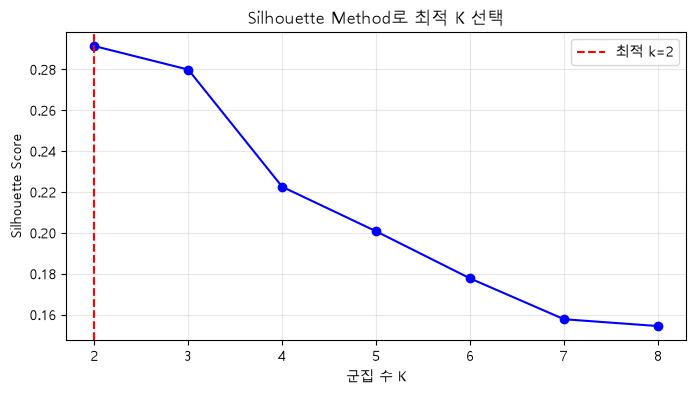


[군집별 고객 수]
cluster
0    1526
1    5517
Name: count, dtype: int64

[군집별 연속형 변수 평균]
         tenure  MonthlyCharges  TotalCharges
cluster                                      
0         30.45           22.61         668.1
1         32.86           76.47        2728.3

[군집별 Contract 비율]
Contract  Month-to-month  One year  Two year
cluster                                     
0                  0.343     0.239     0.418
1                  0.607     0.201     0.192

[군집별 InternetService 비율]
InternetService   DSL  Fiber optic    No
cluster                                 
0                0.00         0.02  0.98
1                0.43         0.57  0.00

[군집별 PaymentMethod 비율]
PaymentMethod  Bank transfer (automatic)  Credit card (automatic)  \
cluster                                                             
0                                  0.211                    0.212   
1                                  0.212                    0.209   

PaymentMethod  Electronic check  Mailed che

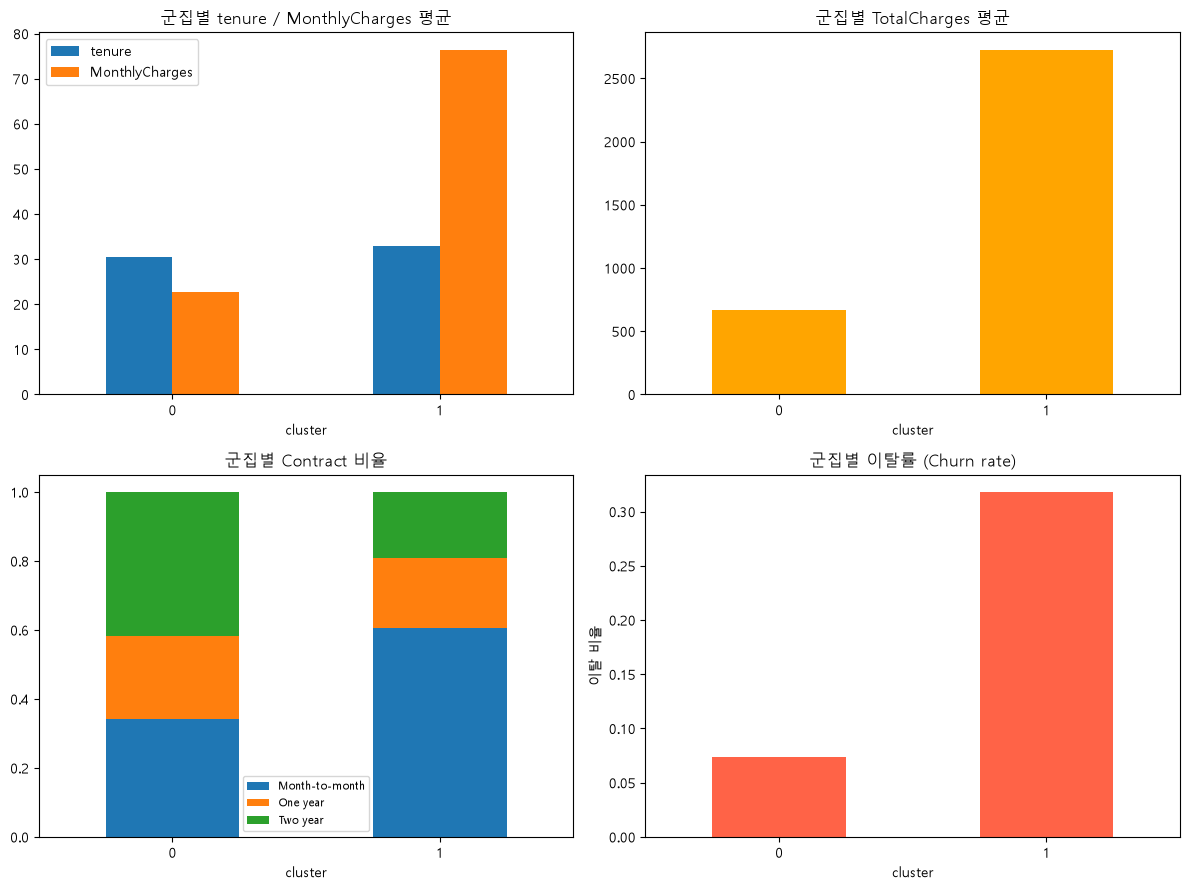


[군집 세그먼트 이름 제안]
  cluster 0 (1526명): 전화전용·안정형 (Budget Phone Loyal)
    - tenure 평균: 30.4개월
    - MonthlyCharges 평균: 22.6
    - 이탈률: 7.4%
  cluster 1 (5517명): 인터넷·고과금·이탈위험형 (Internet High-Risk)
    - tenure 평균: 32.9개월
    - MonthlyCharges 평균: 76.5
    - 이탈률: 31.8%


In [36]:
# ============================================================
# 3-1) K-Means Clustering
#  - X: 전처리 완료된 입력 변수 (스케일링 + 인코딩)
#  - data: 원본 스케일의 값 (해석·이름 붙일 때 사용)
#  - churn: 군집 학습에는 넣지 않고, 군집별 이탈률 해석용으로만 사용
# ============================================================

# ------------------------------------------------------------
# 1. Silhouette Score로 최적 군집 수 k 찾기
# ------------------------------------------------------------
# 실루엣 점수: 각 데이터가 "자신의 군집"과 얼마나 잘 맞고,
#             "다른 군집"과 얼마나 잘 구분되는지를 -1~1로 요약한 값
#   · 1에 가까울수록 잘 나뉜 군집
#   · 0 근처면 경계가 모호함
#   · 음수면 잘못된 군집에 배정된 상태가 많음
#
# K-Means는 k를 사람이 지정해야 하므로,
# k=2~8을 바꿔 가며 점수를 비교하고 가장 높은 k를 고른다.

sil_scores = []          # k별 실루엣 점수를 담을 리스트
K_range = range(2, 9)    # 평가할 군집 수 후보 (보통 2부터 시작)

for k in K_range:
    # n_init=10: 초기 중심을 10번 다르게 잡아 그중 가장 좋은 결과 사용
    # random_state=42: 재현 가능한 결과를 위해 난수 고정
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = kmeans_tmp.fit_predict(X)  # 각 고객의 임시 군집 번호
    score = silhouette_score(X, labels_tmp)  # 현재 k의 실루엣 점수
    sil_scores.append(score)
    print(f"k={k} | Silhouette Score = {score:.4f}")

# 실루엣 점수가 가장 높은 k를 최적값으로 선택
best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"\n>>> 실루엣 기준 최적 k = {best_k} (점수: {max(sil_scores):.4f})")

# k별 실루엣 점수 시각화 → 봉우리(최고점)가 최적 k
plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, "bo-")
plt.axvline(best_k, color="red", linestyle="--", label=f"최적 k={best_k}")
plt.xlabel("군집 수 K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method로 최적 K 선택")
plt.xticks(list(K_range))
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 2. 최적 k로 K-Means 최종 학습
# ------------------------------------------------------------
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
# 학습에 쓰는 것은 전처리된 X, 해석용으로 원본 data에 군집 번호만 붙임
data["cluster"] = kmeans_final.fit_predict(X)

# 군집별 고객 수 확인
print("\n[군집별 고객 수]")
print(data["cluster"].value_counts().sort_index())


# ------------------------------------------------------------
# 3. 군집별 특징 파악 (해석은 원본 스케일의 data 사용)
# ------------------------------------------------------------
# 이탈 여부를 0/1로 바꿔 군집별 이탈률을 계산하기 쉽게 만듦
data["Churn_bin"] = (churn == "Yes").astype(int)

# (1) 주요 연속형 변수 평균: tenure(가입기간), MonthlyCharges, TotalCharges
print("\n[군집별 연속형 변수 평균]")
num_profile = data.groupby("cluster")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2)
print(num_profile)

# (2) 계약 형태(Contract) 비율 — 단기/장기 계약 성향
print("\n[군집별 Contract 비율]")
contract_profile = pd.crosstab(data["cluster"], data["Contract"], normalize="index").round(3)
print(contract_profile)

# (3) 인터넷 서비스(InternetService) 비율 — DSL / Fiber / 없음
print("\n[군집별 InternetService 비율]")
internet_profile = pd.crosstab(data["cluster"], data["InternetService"], normalize="index").round(3)
print(internet_profile)

# (4) 결제 방식(PaymentMethod) 비율
print("\n[군집별 PaymentMethod 비율]")
pay_profile = pd.crosstab(data["cluster"], data["PaymentMethod"], normalize="index").round(3)
print(pay_profile)

# (5) 군집별 이탈률 (학습에는 안 썼지만, 비즈니스 해석에 핵심)
print("\n[군집별 이탈률]")
churn_rate = data.groupby("cluster")["Churn_bin"].mean().round(3)
print(churn_rate)

# (6) 가족·연령 관련 보조 지표
print("\n[군집별 Partner / Dependents / SeniorCitizen 비율]")
for c in sorted(data["cluster"].unique()):
    sub = data[data["cluster"] == c]
    print(
        f"cluster {c} | Partner Yes: {(sub['Partner']=='Yes').mean():.3f} | "
        f"Dependents Yes: {(sub['Dependents']=='Yes').mean():.3f} | "
        f"SeniorCitizen: {sub['SeniorCitizen'].mean():.3f}"
    )


# ------------------------------------------------------------
# 4. 주요 변수 시각화로 군집 차이 한눈에 보기
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 가입기간 / 월요금: 군집별 평균 막대그래프
num_profile[["tenure", "MonthlyCharges"]].plot(kind="bar", ax=axes[0, 0], rot=0)
axes[0, 0].set_title("군집별 tenure / MonthlyCharges 평균")
axes[0, 0].set_xlabel("cluster")

# 총요금
num_profile[["TotalCharges"]].plot(kind="bar", ax=axes[0, 1], rot=0, color="orange", legend=False)
axes[0, 1].set_title("군집별 TotalCharges 평균")
axes[0, 1].set_xlabel("cluster")

# Contract 비율 (stacked bar)
contract_profile.plot(kind="bar", stacked=True, ax=axes[1, 0], rot=0)
axes[1, 0].set_title("군집별 Contract 비율")
axes[1, 0].set_xlabel("cluster")
axes[1, 0].legend(fontsize=8)

# 이탈률
churn_rate.plot(kind="bar", ax=axes[1, 1], rot=0, color="tomato")
axes[1, 1].set_title("군집별 이탈률 (Churn rate)")
axes[1, 1].set_xlabel("cluster")
axes[1, 1].set_ylabel("이탈 비율")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. 고객 세그먼트 이름 붙이기 (해석)
# ------------------------------------------------------------
# ※ 아래 이름은 위 프로파일 결과를 보고 붙인 예시이다.
#    실루엣 최적 k=2일 때의 전형적인 패턴:
#
#  [cluster 0] 거의 전원이 인터넷 미이용(No), 월요금이 매우 낮음(~23),
#              2년 계약 비중이 높고, 이탈률이 매우 낮음(~7%)
#   → 이름 예: "전화전용·안정형 (Budget Phone Loyal)"
#   → 특징: 저가 전화 중심, 장기 계약, 이탈 위험 낮음
#
#  [cluster 1] DSL/Fiber 인터넷 이용, 월요금이 높음(~76),
#              Month-to-month 비중이 크고, 이탈률이 높음(~32%)
#   → 이름 예: "인터넷·고과금·이탈위험형 (Internet High-Risk)"
#   → 특징: 인터넷(특히 Fiber) + 단기 계약 + 높은 이탈 가능성
#
# 마케팅 관점 한 줄 요약:
#  - cluster 0: 유지 비용이 낮고 충성도가 높음 → 기존 요금제 유지/묶음 상품 가벼운 제안
#  - cluster 1: 이탈 위험이 큼 → 약정 전환 할인, 부가서비스 만족도·요금 부담 점검이 우선

segment_names = {
    0: "전화전용·안정형 (Budget Phone Loyal)",
    1: "인터넷·고과금·이탈위험형 (Internet High-Risk)",
}

# best_k가 2가 아닐 수도 있으므로, 존재하는 군집만 출력
print("\n[군집 세그먼트 이름 제안]")
for c in sorted(data["cluster"].unique()):
    name = segment_names.get(c, f"세그먼트 {c} (프로파일 재확인 필요)")
    n = (data["cluster"] == c).sum()
    print(f"  cluster {c} ({n}명): {name}")
    print(f"    - tenure 평균: {num_profile.loc[c, 'tenure']:.1f}개월")
    print(f"    - MonthlyCharges 평균: {num_profile.loc[c, 'MonthlyCharges']:.1f}")
    print(f"    - 이탈률: {churn_rate.loc[c]:.1%}")


### 3-2) DBSCAN 적용

**[과제]** 

AI와 함께 최적의 eps를 찾아 DBSCAN을 학습시켜 보세요.

K-Means와 결과가 어떻게 다른지, Noise로 분류된 고객들은 어떤 특징을 보이는지 확인해 보세요.

[프롬프트]
이번에는 K-Means말고 DBSCAN 방법으로 클러스터링을 시행해볼거야. 각 요청별로 Cell을 따로 써서 채팅창에 적어줘.
1. 데이터테이블 'X'에 DBSCAN으로 군집화를 하기위한 최적의 eps값은 어떻게 찾을수 있지?
2. 최적의 eps값을 기반으로 DBSCAN을 시행하고 각 군집의 특징을 파악해서 이름을 붙여줘.
3. Noise로 분류된 고객은 어떤 특징을 가지고 있지?

X 차원 수: 30 → min_samples = 31
k-distance 분위수 | p50=1.736, p75=2.004, p90=2.116, p95=2.230


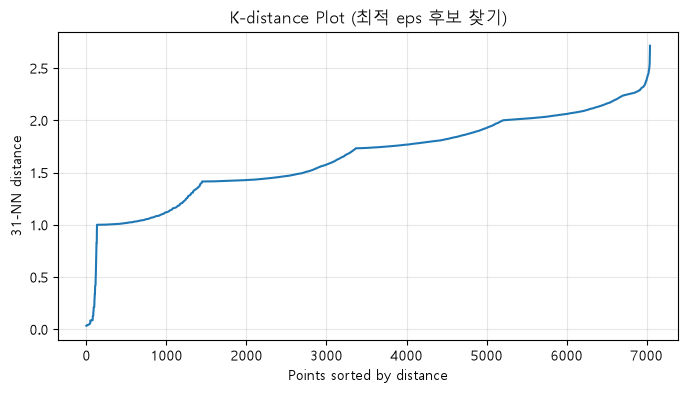


[eps 후보별 DBSCAN 결과 요약]
eps=1.5 | 군집 수=3 | Noise=2662 (37.8%)
eps=2.0 | 군집 수=2 | Noise=278 (3.9%)
eps=2.5 | 군집 수=2 | Noise=0 (0.0%)
eps=3.0 | 군집 수=1 | Noise=0 (0.0%)

>>> 선택 최적 eps = 2.0 (min_samples=31)


In [37]:
# ============================================================
# Cell 1. DBSCAN 최적 eps 찾기 (K-distance Plot)
# ============================================================
# DBSCAN 핵심 하이퍼파라미터
#   - eps        : "이웃"으로 인정할 최대 거리(반경)
#   - min_samples: Core Point가 되기 위한 최소 이웃 개수
#
# eps를 고르는 대표적 방법 = K-distance Plot
#   1) 각 점에서 min_samples번째로 가까운 이웃까지의 거리를 계산
#   2) 그 거리를 오름차순으로 정렬해 그림
#   3) 그래프가 갑자기 급상승하는 지점(Elbow) 직전 y값을 eps 후보로 선택
#      → Elbow 이전: 밀도가 높은 구간(군집에 속할 가능성↑)
#      → Elbow 이후: 멀리 떨어진 점(Noise 후보)

from sklearn.neighbors import NearestNeighbors

# 고차원일 때 관례: min_samples ≈ 차원 수 + 1
# (X는 One-Hot 등으로 차원이 커진 상태)
min_samples = X.shape[1] + 1
print(f"X 차원 수: {X.shape[1]} → min_samples = {min_samples}")

# 각 점의 k번째 이웃 거리 계산 (k = min_samples)
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# distances[:, min_samples-1] : "min_samples번째 이웃"까지의 거리
k_distances = np.sort(distances[:, min_samples - 1])

# 참고용 분위수 (Elbow를 눈으로 고를 때 도움)
print(
    f"k-distance 분위수 | "
    f"p50={np.percentile(k_distances, 50):.3f}, "
    f"p75={np.percentile(k_distances, 75):.3f}, "
    f"p90={np.percentile(k_distances, 90):.3f}, "
    f"p95={np.percentile(k_distances, 95):.3f}"
)

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("K-distance Plot (최적 eps 후보 찾기)")
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Elbow 근처 eps 후보 몇 개를 직접 비교
#  - eps가 너무 작으면: 군집이 잘게 쪼개지거나 Noise↑
#  - eps가 너무 크면: 거의 한 덩어리로 합쳐짐
# ------------------------------------------------------------
eps_candidates = [1.5, 2.0, 2.5, 3.0]

print("\n[eps 후보별 DBSCAN 결과 요약]")
for eps in eps_candidates:
    labels_tmp = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    n_clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_noise = list(labels_tmp).count(-1)
    print(
        f"eps={eps:.1f} | 군집 수={n_clusters} | "
        f"Noise={n_noise} ({100 * n_noise / len(labels_tmp):.1f}%)"
    )

# 이 데이터에서 K-distance Elbow ≈ 2.0 부근이 적절
# (군집 2개 + Noise 약 4% → 해석에 쓸 Noise도 남김)
best_eps = 2.0
print(f"\n>>> 선택 최적 eps = {best_eps} (min_samples={min_samples})")

이 셀에서 고르는 값 (실행 기준)

min_samples = 31 (차원 30 + 1)
최적 eps ≈ 2.0
eps=1.5: Noise 과다(~50%)
eps=2.0: 군집 2개 + Noise ~4% ← 추천
eps=2.5+: Noise 거의/전혀 없음, 또는 군집이 하나로 합쳐짐

군집 수: 2, Noise: 278

[라벨별 고객 수] (-1 = Noise)
cluster_dbscan
-1     278
 0    5242
 1    1523
Name: count, dtype: int64

[군집별 연속형 변수 평균]
                tenure  MonthlyCharges  TotalCharges
cluster_dbscan                                      
0                32.33           77.28       2732.15
1                30.42           22.48        667.35

[군집별 Contract 비율]
Contract        Month-to-month  One year  Two year
cluster_dbscan                                    
0                        0.631     0.179     0.190
1                        0.344     0.237     0.419

[군집별 InternetService 비율]
InternetService    DSL  Fiber optic    No
cluster_dbscan                           
0                0.408        0.592  0.00
1                0.000        0.020  0.98

[군집별 PaymentMethod 비율]
PaymentMethod   Bank transfer (automatic)  Credit card (automatic)  \
cluster_dbscan                                                       
0                                   0.213                    0.201   
1

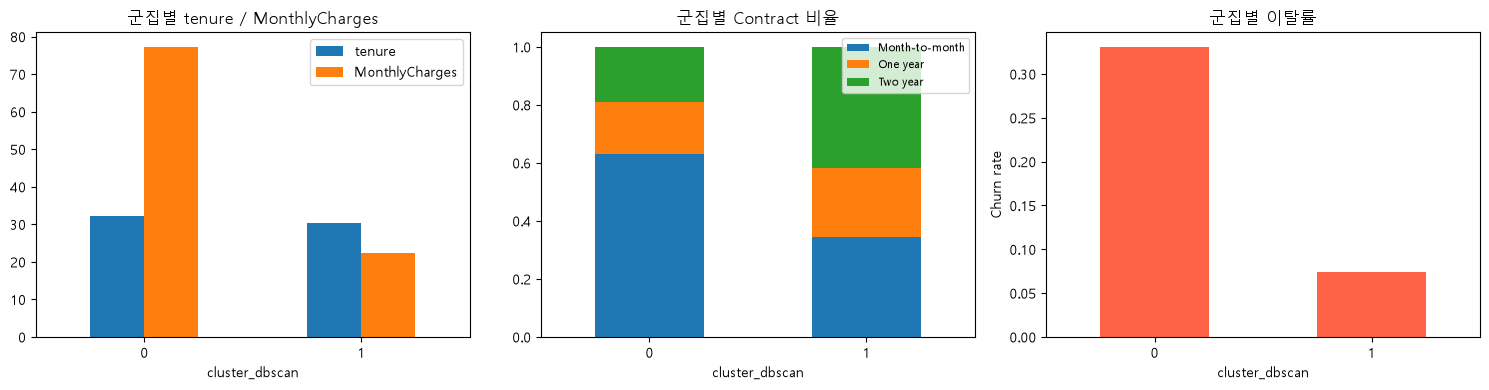


[DBSCAN 군집 이름 제안]
  cluster 0 (5242명): 인터넷·고과금·이탈위험형 (Internet High-Risk)
    - tenure 평균: 32.3
    - MonthlyCharges 평균: 77.3
    - 이탈률: 33.1%
  cluster 1 (1523명): 전화전용·안정형 (Budget Phone Loyal)
    - tenure 평균: 30.4
    - MonthlyCharges 평균: 22.5
    - 이탈률: 7.4%


In [38]:
# ============================================================
# Cell 2. 최적 eps로 DBSCAN 실행 + 군집 특징 파악 / 이름 붙이기
# ============================================================

# Cell 1에서 정한 값 사용 (단독 실행 시 아래 두 줄을 다시 지정)
# min_samples = X.shape[1] + 1
# best_eps = 2.0

dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
data["cluster_dbscan"] = dbscan.fit_predict(X)  # -1 = Noise

# 군집 수 / Noise 수
n_clusters = len(set(data["cluster_dbscan"])) - (1 if -1 in data["cluster_dbscan"].values else 0)
n_noise = (data["cluster_dbscan"] == -1).sum()
print(f"군집 수: {n_clusters}, Noise: {n_noise}")
print("\n[라벨별 고객 수] (-1 = Noise)")
print(data["cluster_dbscan"].value_counts().sort_index())

# 해석용: 원본 스케일 data + 이탈 여부
data["Churn_bin"] = (churn == "Yes").astype(int)

# 실제 군집만(라벨 >= 0) 프로파일링
cluster_mask = data["cluster_dbscan"] >= 0
clusters_only = data.loc[cluster_mask]

print("\n[군집별 연속형 변수 평균]")
num_profile = clusters_only.groupby("cluster_dbscan")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean().round(2)
print(num_profile)

print("\n[군집별 Contract 비율]")
print(pd.crosstab(clusters_only["cluster_dbscan"], clusters_only["Contract"], normalize="index").round(3))

print("\n[군집별 InternetService 비율]")
print(pd.crosstab(clusters_only["cluster_dbscan"], clusters_only["InternetService"], normalize="index").round(3))

print("\n[군집별 PaymentMethod 비율]")
print(pd.crosstab(clusters_only["cluster_dbscan"], clusters_only["PaymentMethod"], normalize="index").round(3))

print("\n[군집별 이탈률]")
churn_rate = clusters_only.groupby("cluster_dbscan")["Churn_bin"].mean().round(3)
print(churn_rate)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

num_profile[["tenure", "MonthlyCharges"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("군집별 tenure / MonthlyCharges")

pd.crosstab(
    clusters_only["cluster_dbscan"], clusters_only["Contract"], normalize="index"
).plot(kind="bar", stacked=True, ax=axes[1], rot=0)
axes[1].set_title("군집별 Contract 비율")
axes[1].legend(fontsize=8)

churn_rate.plot(kind="bar", ax=axes[2], rot=0, color="tomato")
axes[2].set_title("군집별 이탈률")
axes[2].set_ylabel("Churn rate")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 세그먼트 이름 제안 (eps=2.0, min_samples=31 기준 결과)
# ------------------------------------------------------------
# cluster 0 (~5242명)
#   - Fiber/DSL 인터넷 이용, 월요금 높음(~77)
#   - Month-to-month 비중 큼(~63%), Electronic check 많음
#   - 이탈률 높음(~33%)
#   → "인터넷·고과금·이탈위험형"
#
# cluster 1 (~1523명)
#   - 거의 전부 인터넷 없음(~98%), 월요금 낮음(~22)
#   - 전화 서비스 100%, Two year 계약 비중 상대적으로 큼
#   - 이탈률 낮음(~7%)
#   → "전화전용·안정형"
#
# ※ K-Means(k=2)와 큰 줄기는 비슷하지만,
#    DBSCAN은 "어디에도 못 끼는 고객"을 Noise(-1)로 따로 뺌

segment_names = {
    0: "인터넷·고과금·이탈위험형 (Internet High-Risk)",
    1: "전화전용·안정형 (Budget Phone Loyal)",
}

print("\n[DBSCAN 군집 이름 제안]")
for c in sorted(clusters_only["cluster_dbscan"].unique()):
    n = (data["cluster_dbscan"] == c).sum()
    print(f"  cluster {c} ({n}명): {segment_names.get(c, '이름 재확인 필요')}")
    print(f"    - tenure 평균: {num_profile.loc[c, 'tenure']:.1f}")
    print(f"    - MonthlyCharges 평균: {num_profile.loc[c, 'MonthlyCharges']:.1f}")
    print(f"    - 이탈률: {churn_rate.loc[c]:.1%}")

Noise 고객 수: 278명 (3.9%)
군집 소속 고객 수: 6765명

[연속형 평균 비교]
                  Noise  Clustered      All
tenure            43.08      31.90    32.34
MonthlyCharges    61.28      64.94    64.80
TotalCharges    2637.50    2267.30  2281.92

[Noise | Contract 비율]
Contract
One year          0.619
Two year          0.223
Month-to-month    0.158
Name: proportion, dtype: float64

[Noise | InternetService 비율]
InternetService
DSL            0.853
Fiber optic    0.137
No             0.011
Name: proportion, dtype: float64

[Noise | PhoneService 비율]
PhoneService
No     0.504
Yes    0.496
Name: proportion, dtype: float64

[Noise | PaymentMethod 비율]
PaymentMethod
Credit card (automatic)      0.367
Mailed check                 0.234
Bank transfer (automatic)    0.209
Electronic check             0.191
Name: proportion, dtype: float64

[Noise | Partner / Dependents / SeniorCitizen / 이탈률]
  Partner Yes     : 0.694
  Dependents Yes  : 0.518
  SeniorCitizen   : 0.191
  Churn rate      : 0.076


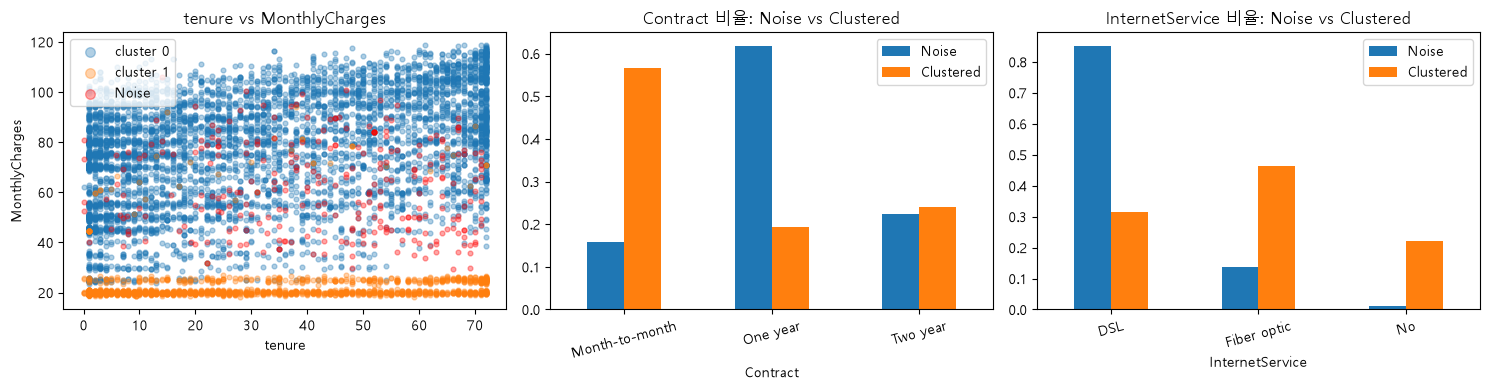


[Noise 세그먼트 한 줄]
DSL 중심 + 1년 약정 + (전화 없음 등) 희귀 조합이 많은,
주류 2군집 사이의 '이질적이지만 이탈은 낮은' 고객군



In [39]:
# ============================================================
# Cell 3. Noise로 분류된 고객 특징 분석
# ============================================================
# DBSCAN에서 label = -1 은
#   "eps 반경 안에 이웃이 충분히 없어 어떤 군집에도 못 들어간 점"
# 즉, 밀도가 낮은 영역에 있는 이질적인(outlier-like) 고객이다.

noise = data[data["cluster_dbscan"] == -1]
normal = data[data["cluster_dbscan"] >= 0]

print(f"Noise 고객 수: {len(noise)}명 ({100 * len(noise) / len(data):.1f}%)")
print(f"군집 소속 고객 수: {len(normal)}명")

# (1) 연속형: Noise vs 전체 / 군집 소속 비교
compare_num = pd.DataFrame({
    "Noise": noise[["tenure", "MonthlyCharges", "TotalCharges"]].mean(),
    "Clustered": normal[["tenure", "MonthlyCharges", "TotalCharges"]].mean(),
    "All": data[["tenure", "MonthlyCharges", "TotalCharges"]].mean(),
}).round(2)
print("\n[연속형 평균 비교]")
print(compare_num)

# (2) 범주형 분포
print("\n[Noise | Contract 비율]")
print(noise["Contract"].value_counts(normalize=True).round(3))

print("\n[Noise | InternetService 비율]")
print(noise["InternetService"].value_counts(normalize=True).round(3))

print("\n[Noise | PhoneService 비율]")
print(noise["PhoneService"].value_counts(normalize=True).round(3))

print("\n[Noise | PaymentMethod 비율]")
print(noise["PaymentMethod"].value_counts(normalize=True).round(3))

print("\n[Noise | Partner / Dependents / SeniorCitizen / 이탈률]")
print(f"  Partner Yes     : {(noise['Partner']=='Yes').mean():.3f}")
print(f"  Dependents Yes  : {(noise['Dependents']=='Yes').mean():.3f}")
print(f"  SeniorCitizen   : {noise['SeniorCitizen'].mean():.3f}")
print(f"  Churn rate      : {noise['Churn_bin'].mean():.3f}")

# (3) 군집 0/1 대비 Noise가 튀는 지점 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 가입기간·월요금: Noise가 중간에 걸쳐 있는지 확인
for label, sub, color, name in [
    (0, data[data["cluster_dbscan"] == 0], "C0", "cluster 0"),
    (1, data[data["cluster_dbscan"] == 1], "C1", "cluster 1"),
    (-1, noise, "red", "Noise"),
]:
    axes[0].scatter(
        sub["tenure"], sub["MonthlyCharges"],
        s=12, alpha=0.35, c=color, label=name
    )
axes[0].set_xlabel("tenure")
axes[0].set_ylabel("MonthlyCharges")
axes[0].set_title("tenure vs MonthlyCharges")
axes[0].legend(markerscale=2)

# Contract 비교 (Noise vs 전체 군집)
pd.DataFrame({
    "Noise": noise["Contract"].value_counts(normalize=True),
    "Clustered": normal["Contract"].value_counts(normalize=True),
}).fillna(0).plot(kind="bar", ax=axes[1], rot=15)
axes[1].set_title("Contract 비율: Noise vs Clustered")

# InternetService 비교
pd.DataFrame({
    "Noise": noise["InternetService"].value_counts(normalize=True),
    "Clustered": normal["InternetService"].value_counts(normalize=True),
}).fillna(0).plot(kind="bar", ax=axes[2], rot=15)
axes[2].set_title("InternetService 비율: Noise vs Clustered")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Noise 해석 요약 (eps=2.0 기준 실측)
# ------------------------------------------------------------
# Noise (~278명, 약 4%)의 특징:
#   1) tenure가 더 김(~43개월) — 오래 남은 고객
#   2) 월요금은 중간(~61) — cluster0(고과금)과 cluster1(저과금) 사이
#   3) Contract는 One year 비중이 매우 큼(~62%)
#      → 단기(Month-to-month)도, 전화전용 장기(Two year)도 아닌 "중간형"
#   4) Internet은 DSL이 압도적(~85%), Fiber/무인터넷 군집과도 안 맞음
#   5) PhoneService No 비율이 약 50% — "DSL + 전화 없음" 같은 소수 조합
#   6) Partner Yes(~69%)가 높고, 이탈률은 오히려 낮음(~7.6%)
#
# 한 줄 해석:
#   Noise는 "고장" 고객이 아니라,
#   주류 2개 세그먼트(고과금 인터넷 / 전화전용 저가)의
#   경계·희귀 조합에 있는 고객이다.
#   → 별도 세그먼트 후보: "DSL·중기약정·이질조합형 (Atypical DSL Loyal)"
print("""
[Noise 세그먼트 한 줄]
DSL 중심 + 1년 약정 + (전화 없음 등) 희귀 조합이 많은,
주류 2군집 사이의 '이질적이지만 이탈은 낮은' 고객군
""")

## 선생님 정리

| 질문 | 답 |
|------|----|
| **1. 최적 eps?** | K-distance Plot의 Elbow. 여기선 `min_samples=31`, **`eps≈2.0`** |
| **2. 군집 이름?** | **0** = 인터넷·고과금·이탈위험형 / **1** = 전화전용·안정형 (K-Means와 유사) |
| **3. Noise?** | 약 **4%**. DSL·1년 약정·전화 없음 등 **희귀 조합**, 가입기간 길고 이탈률은 **오히려 낮음** |

K-Means와의 차이: K-Means는 전원에게 라벨을 강제 부여하고, DBSCAN은 “어디에도 안 맞는” 고객을 **Noise(-1)**로 남겨 둡니다.